### Downloads

Huspunkt er hentet fra GeoNorge: https://kartkatalog.geonorge.no/metadata/matrikkelen-bygningspunkt/24d7e9d1-87f6-45a0-b38e-3447f8d7f9a1  
Brannstasjoner er lastet ned fra GeoNorge: http://kartkatalog.geonorge.no/metadata/brannstasjoner/0ccce81d-a72e-46ca-8bd9-57b362376485  
DEM er lastet ned fra GeoNorge for områder 6400-1 : https://kartkatalog.geonorge.no/metadata/dtm-10-terrengmodell-utm33/dddbb667-1303-4ac5-8640-7ec04c0e3918  

## Download and tranform data


### Importerer biblioteker
Denne cellen impporterer biblioteker som skal brukes i hele oppgaven.


In [ ]:
import pandas as pd
import geopandas as gpd
import duckdb
import matplotlib.pyplot as plt


### Initialiserer DuckDB
Denne cellen initialiserer DuckDB og loader spatial extension for brannstasjoner. Gjør klar for spatial SQL.

In [9]:

con = duckdb.connect("/home/lanjon/Documents/is_218_2/fire_analysis.duckdb")
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

### Initialiserer DuckDB
Denne cellen initialiserer DuckDB og loader spatial extension for byggningspunkt. Gjør klar for spatial SQL.

In [10]:
con = duckdb.connect("/home/lanjon/Documents/is_218_2/house_analysis.duckdb")
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")



### Ingest fire station dataset
Denne cellen leser brannstasjoner fra FileGDB inn i DuckDB ved hjelp av `ST_Read`. Tabellen blir kjernen for analysen.


In [11]:
fgdb_path = "/home/lanjon/Documents/is_218_2/Samfunnssikkerhet_42_Agder_25832_Brannstasjoner_FGDB.gdb"

con.execute(f"""
CREATE OR REPLACE TABLE firestations AS
SELECT
    brannstasjon,
    brannvesen,
    CAST(SHAPE AS GEOMETRY) AS geom
FROM ST_Read(
    '{fgdb_path}',
    layer='brannstasjoner_brannstasjon',
    allowed_drivers=['OpenFileGDB']
);
""")

### Ingest building dataset
Denne cellen leser byggningspunkt fra FileGDB inn i DuckDB ved hjelp av `ST_Read`. Bruker `COUNT(*)` for å verifisere at dette ble gjort riktig.

In [12]:
houses_path = "/home/lanjon/Documents/is_218_2/Basisdata_42_Agder_25832_MatrikkelenBygning_FGDB.gdb"

con.execute(f"""
CREATE OR REPLACE TABLE houses AS
SELECT
    CAST(SHAPE AS GEOMETRY) AS geom,
    *
EXCLUDE (SHAPE)
FROM ST_Read(
    '{houses_path}',
    layer='bygning',
    allowed_drivers=['OpenFileGDB']
);
""")

con.execute("SELECT COUNT(*) AS n_houses FROM houses").df()

,n_houses
0,299391



### Load Brannstasjoner inn i GeoPandas
Denne cellen leser brannstasjoner fra filegdb inn i GeoPandas og projiserer til meter-basert CRS.

In [13]:
fire = gpd.read_file(fgdb_path, layer="brannstasjoner_brannstasjon")
fire = fire.to_crs(25832)  # meter-basert CRS
fire[["brannstasjon", "brannvesen"]].head()

,brannstasjon,brannvesen
0,Kvinlog,Brannvesenet Sør IKS
1,Vegårshei,Østre Agder Brannvesen
2,Spangereid,Brannvesenet Sør IKS
3,Valle,Setesdal Brannvesen IKS
4,Risør,Østre Agder Brannvesen



### Lager buffer for brannstasjoner
Denne cellen lager en 10000 meter buffer rundt hver brannstasjon.

In [14]:
con.execute("""
CREATE OR REPLACE TABLE firestation_buffers AS
SELECT
    brannstasjon,
    brannvesen,
    ST_Buffer(geom, 10000) AS geom  -- 10000 meters
FROM firestations;
""")

### Overlay-analyse: intersection mellom bygninger og buffersoner
I denne cellen utfører jeg en overlay-operasjon med `ST_Intersection` for å lage et nytt geometrlag av overlap mellom bygninger og 10 km buffersoner rundt brannstasjoner.

In [15]:
con.execute("""
CREATE OR REPLACE TABLE houses_buffer_intersection AS
SELECT
    h.bygningid,
    f.brannstasjon,
    ST_Intersection(h.geom, f.geom) AS geom
FROM houses h
JOIN firestation_buffers f
  ON ST_Intersects(h.geom, f.geom)
WHERE NOT ST_IsEmpty(ST_Intersection(h.geom, f.geom));
""")

con.execute("""
SELECT COUNT(*) AS n_intersections
FROM houses_buffer_intersection;
""").df()

,n_intersections
0,358711


### Aggregerer byggninger per brannstasjon
Denne cellen aggregerer byggninger per brannstasjon ved å bruke `ST_Within` for å se om byggningen ligger innenfor 10km av brannstasjonen.


In [16]:
result = con.execute("""
SELECT
    f.brannstasjon,
    f.brannvesen,
    COUNT(h.*) AS houses_within_10km
FROM firestation_buffers f
LEFT JOIN houses h
    ON ST_Within(h.geom, f.geom)
GROUP BY f.brannstasjon, f.brannvesen
ORDER BY houses_within_10km DESC;
""").df()

result.head(20)

,brannstasjon,brannvesen,houses_within_10km
0,Kristiansand,Kristiansandsregionen BR,49334
1,Arendal,Østre Agder Brannvesen,40468
2,Moland,Østre Agder Brannvesen,30014
3,Søgne,Kristiansandsregionen BR,23458
4,Grimstad,Grimstad brann- og feiertjenesten,21096
5,Froland,Østre Agder Brannvesen,15946
6,Vennesla,Kristiansandsregionen BR,13937
7,Mandal,Brannvesenet Sør IKS,13718
8,Tvedestrand,Østre Agder Brannvesen,11960
9,Lillesand,Kristiansandsregionen BR,11016


### Tell hvor mange bygninger som er innenfor en buffer
Denne cellen teller unike bygninger som ligger innenfor en buffer. Unngår duplikater når bygninger er dekket av flere buffere.

In [17]:
con.execute("""
SELECT COUNT(DISTINCT h.bygningid) AS houses_inside_any_buffer
FROM houses h
JOIN firestation_buffers f
  ON ST_Within(h.geom, f.geom);
""").df()

,houses_inside_any_buffer
0,268203


### Beregn dekningsprosent
Denne cellen beregner total bygninger, dekket bygninger og dekningsprosent.


In [18]:
con.execute("""
WITH total AS (
  SELECT COUNT(DISTINCT bygningid) AS total_houses
  FROM houses
),
covered AS (
  SELECT COUNT(DISTINCT h.bygningid) AS covered_houses
  FROM houses h
  JOIN firestation_buffers f
    ON ST_Within(h.geom, f.geom)
)
SELECT
  total.total_houses,
  covered.covered_houses,
  ROUND(100.0 * covered.covered_houses / total.total_houses, 2) AS pct_covered
FROM total, covered;
""").df()

,total_houses,covered_houses,pct_covered
0,299391,268203,89.58


### Klargjor buffersoner for plotting i GeoPandas
I denne cellen henter jeg buffersonene rundt brannstasjoner fra DuckDB-tabellen `firestation_buffers`. Geometrien leses ut som WKB (`ST_AsWKB`) og konverteres fra `bytearray` til `bytes` slik at den kan leses av GeoPandas. Til slutt oppretter jeg et `GeoDataFrame` med CRS `EPSG:25832`, klart for videre visualisering sammen med brannstasjoner og bygninger.

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Firestations from your existing GeoPandas object (already loaded earlier)
fire_plot = fire[["brannstasjon", "geometry"]].copy()

buffers_df = con.execute("""
SELECT brannstasjon, ST_AsWKB(geom) AS geom_wkb
FROM firestation_buffers
""").df()

# Convert bytearray -> bytes
buffers_df["geom_wkb"] = buffers_df["geom_wkb"].apply(
    lambda x: bytes(x) if x is not None else None
)

buffers = gpd.GeoDataFrame(
    buffers_df.drop(columns="geom_wkb"),
    geometry=gpd.GeoSeries.from_wkb(buffers_df["geom_wkb"]),
    crs="EPSG:25832"
)


### Lag inn/ute bygninger
Denne cellen lager to grupper bygninger: de som ligger innenfor en brannstasjon buffer og de som ligger utenfor alle buffere.


In [20]:
# Houses INSIDE any firestation buffer
inside_df = con.execute("""
SELECT DISTINCT h.bygningid, ST_AsWKB(h.geom) AS geom_wkb
FROM houses h
JOIN firestation_buffers f
  ON ST_Within(h.geom, f.geom)
""").df()
inside_df["geom_wkb"] = inside_df["geom_wkb"].apply(lambda x: bytes(x) if x is not None else None)

houses_inside = gpd.GeoDataFrame(
    inside_df.drop(columns="geom_wkb"),
    geometry=gpd.GeoSeries.from_wkb(inside_df["geom_wkb"]),
    crs="EPSG:25832"
)

# Houses OUTSIDE all buffers
outside_df = con.execute("""
SELECT h.bygningid, ST_AsWKB(h.geom) AS geom_wkb
FROM houses h
WHERE NOT EXISTS (
    SELECT 1
    FROM firestation_buffers f
    WHERE ST_Within(h.geom, f.geom)
)
""").df()
outside_df["geom_wkb"] = outside_df["geom_wkb"].apply(lambda x: bytes(x) if x is not None else None)

houses_outside = gpd.GeoDataFrame(
    outside_df.drop(columns="geom_wkb"),
    geometry=gpd.GeoSeries.from_wkb(outside_df["geom_wkb"]),
    crs="EPSG:25832"
)


### Plot siste kartlag
Denne cellen visualiserer de siste kartlagene: brannstasjoner, buffere og bygninger innenfor/ute av buffere.

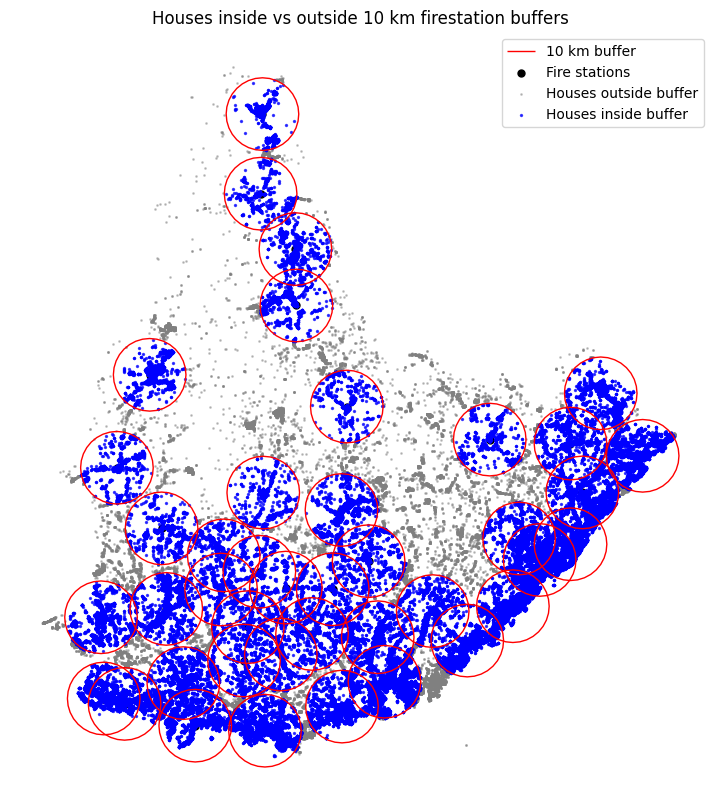

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))

buffers.boundary.plot(ax=ax, color="red", linewidth=1, label="10 km buffer")
fire.plot(ax=ax, color="black", markersize=25, label="Fire stations")
houses_outside.plot(ax=ax, color="gray", markersize=1, alpha=0.4, label="Houses outside buffer")
houses_inside.plot(ax=ax, color="blue", markersize=2, alpha=0.7, label="Houses inside buffer")

ax.set_title("Houses inside vs outside 10 km firestation buffers")
ax.legend()
ax.set_axis_off()
plt.show()


## Rasteranalyse
### Sett DEM path og output filnavn
Denne cellen definerer input/output paths for rasteranalyse og sjekker at DEM filen eksisterer før kjøring av GDAL kommandoer.

In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

# Paths
dem_path = "Basisdata_6400-1_Celle_25833_DTM10UTM33_DEM/6400_1_10m_z33.dem"

slope_tif = "slope_deg.tif"
slope_gt30_tif = "slope_gt30.tif"
slope_poly_gpkg = "slope_gt30.gpkg"
slope_poly_only_gpkg = "slope_gt30_only.gpkg"

hillshade1 = "hillshade_az315_alt45_z1.tif"
hillshade2 = "hillshade_az135_alt35_z2.tif"

print("DEM exists:", os.path.exists(dem_path))

DEM exists: True



### Lag slope raster
Denne cellen lager en slope raster fra DEM ved hjelp av GDAL. Output er raster for å identifisere bratt terreng.

In [2]:
!gdaldem slope "{dem_path}" "{slope_tif}" -of GTiff -p

0...10...20...30...40...50...60...70...80...90...100 - done.



### Filtrerer terreng over 30 grader
Denne cellen filtrerer terreng over 30 grader og lager et binært raster for bratt og ikke bratt terreng.

In [3]:
!gdal_calc.py -A "{slope_tif}" --calc="A>30" --outfile="{slope_gt30_tif}" --type=Byte --NoDataValue=0 --co="COMPRESS=LZW"

0...10...20...30...40...50...60...70...80...90...100 - done.



### Lager polygoner fra bratt terreng
Denne cellen konverterer bratt terreng raster til vektor polygoner.

In [4]:
!gdal_polygonize.py "{slope_gt30_tif}" -f "GPKG" "{slope_poly_gpkg}" slope_gt30 value
!ogr2ogr -f "GPKG" "{slope_poly_only_gpkg}" "{slope_poly_gpkg}" -dialect SQLite -sql "SELECT * FROM slope_gt30 WHERE value = 1"

Creating output slope_gt30.gpkg of format GPKG.
0...10...20...30...40...50...60...70...80...90...100 - done.



### Lager to hillshade rasters
Denne cellen genererer to hillshade rasters med forskjellige azimut, høyde og z-faktor.

In [5]:
!gdaldem hillshade "{dem_path}" "{hillshade1}" -az 315 -alt 45 -z 1
!gdaldem hillshade "{dem_path}" "{hillshade2}" -az 135 -alt 35 -z 2

0...10...20...30...40...50...60...70...80...90...100 - done.
0...10...20...30...40...50...60...70...80...90...100 - done.



### Visualisering av bratt polygoner
Denne cellen visualiserer bratt terreng polygoner med GeoPandas. Figuren viser hvor det er bratt terreng over 30 grader.

Number of steep polygons: 69387


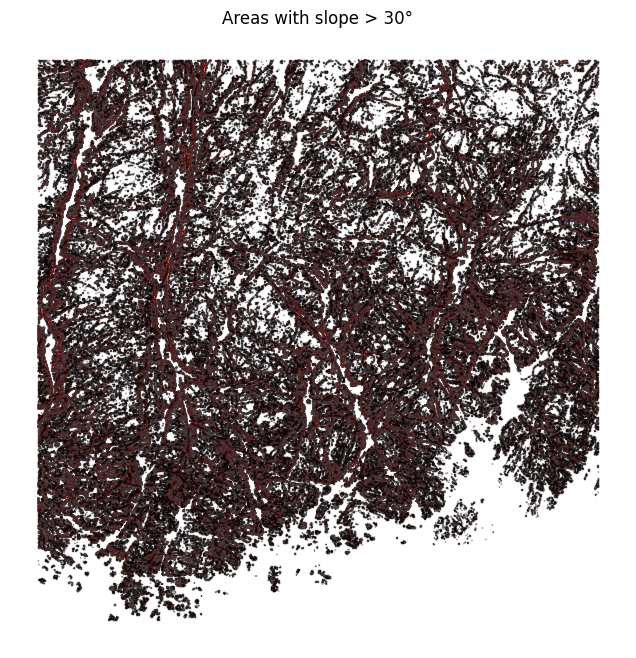

In [6]:
steep = gpd.read_file(slope_poly_only_gpkg)
print("Number of steep polygons:", len(steep))

ax = steep.plot(figsize=(8, 8), color="red", edgecolor="black", alpha=0.7)
ax.set_title("Areas with slope > 30°")
ax.set_axis_off()
plt.show()